In [93]:
import sys
import numpy as np
import torch 
import pandas as pd
# still do preprocessing in scipy
import scipy.sparse as sp
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from importlib import reload
# get UMAP
import umap
import LeafletSC

# Append this directory to sys.path
from LeafletSC.clustering.find_intron_clusters import visualize_local_events
from LeafletSC.beta_binomial_mix.modeling import *
from LeafletSC.beta_binomial_mix.calculate_cellstate_consistency import *
from LeafletSC.clustering.load_cluster_data import *

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor')
import factor_model
reload(factor_model)

import matplotlib.pyplot as plt

from scipy.stats import beta
from sklearn.utils import resample

# define path for saving the output data 
output_path = "/gpfs/commons/projects/knowles_singlecell_splicing/allen-brain/human/lein/"

# we provide a gtf file for the human genome as well to make better sense of the junctions that are detected in cells
# please replace with the path to the gtf file on your system
gtf_file="/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-reference/gencode/gencode.v45.primary_assembly.annotation.gtf" 

# published metadata
metacells = "/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-cortical-taxonomy/General/metadata.csv"
metacells = pd.read_csv(metacells)

2.3.0+cu121
12.1


In [94]:
metacells.region_label.value_counts()

region_label
MTG     16155
V1C      8052
A1C      6703
CgG      6279
M1lm     3371
S1ul     3188
M1ul     2864
S1lm     2805
Name: count, dtype: int64

In [95]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cuda


In [96]:
# read in the metadata file
model_input_file="/gpfs/commons/projects/knowles_singlecell_splicing/allen-brain/human/lein/lein_human_cortex_leaflet.h5"

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data(
     input_file = model_input_file, max_intron_count=100000, remove_singletons=True, has_genes="yes")

# add cluster information to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# generate torch tensors for sparse data representation 
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(final_data, **float_type)

# simplify columns 
simple_data = final_data[["cell_id_index", "Cluster", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]

print("The number of junctions is: ", len(junction_ids_conversion))
print("The number of intron clusters observed is: ", len(junction_ids_conversion.Cluster.unique()))
print("The number of genes is: ", len(junction_ids_conversion.gene_id.unique()))
print("The number of cells is: ", len(simple_data.cell_id_index.unique()))

Reading in data from folder ...
Finished reading in data from folder ...
Removing singletons ...
Number of junctions before removing singletons:  12671
Number of junctions after removing singletons:  12671
The number of unique cell types in the data is:  2721
The number of unique cells in the data is:  2721
The number of unique junctions in the data is:  12672
The maximum junction count was initially:  13895
0
The maximum junction count is now:  13895
The number of junctions in the data is:  12672
The number of cells in the data is:  2721
The number of cell types in the data is:  2721
The number of cells going into training data is:
2721
2721
The number of junctions is:  12672
The number of intron clusters observed is:  4585
The number of genes is:  3381
The number of cells is:  2721


In [97]:
# get indices (maybe don't need this actually)
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

In [98]:
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

In [99]:
indices = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values = torch.tensor(final_data['junc_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells = final_data['cell_id_index'].max() + 1
num_junctions = final_data['junction_id_index'].max() + 1
size = (num_cells, num_junctions)
# Create a sparse tensor
y_tensor = torch.sparse_coo_tensor(indices, values, size)

In [100]:
indices_counts = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values_counts = torch.tensor(final_data['cluster_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells_counts = final_data['cell_id_index'].max() + 1
num_junctions_counts = final_data['junction_id_index'].max() + 1
size_counts = (num_cells_counts, num_junctions_counts)
# Create a sparse tensor
total_counts_tensor = torch.sparse_coo_tensor(indices_counts, values_counts, size_counts)

In [101]:
# save full dataset y_tensor and total_counts_tensor 
full_y_tensor = y_tensor
full_total_counts_tensor = total_counts_tensor

In [102]:
# how many zeroes in the data compared to total number of values
perc_nonzero = cluster_counts.nnz / (cluster_counts.shape[0] * cluster_counts.shape[1])
print("The percentage of missing values in the intron counts matrix is: ", 1-perc_nonzero)

The percentage of missing values in the intron counts matrix is:  0.8417374718797679


### Evaluate performance on imputation/masking task

In [103]:
# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations')
import masking
from masking import *

# import reload 
from importlib import reload
reload(masking)

<module 'masking' from '/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py'>

In [104]:
#1. get masked matrix using intron cluster counts for this mouse brain data 
perc_mask = 0.1
seeds_used = []
masks_list = []

print("The masking percentage is: " + str(perc_mask))
masked_matrix, seed = generate_mask(cluster_counts, mask_percentage = perc_mask, randomize_seed = True)
seeds_used.append(seed)
masks_list.append(masked_matrix)

#2. get junction and intron cluster count matrices via masked values 
masked_counts = []
i=0
print("The masking percentage is: " + str(perc_mask))
masked_junction_counts, masked_intron_clusts = apply_mask(junc_counts, cluster_counts, masks_list[i])
# appent masked junction and intron cluster counts to list
masked_counts.append((masked_junction_counts, masked_intron_clusts))

#3. get input files for factor model (junction and intron cluster sparse tensor)
model_input_files = [] 
masked_junction_counts, masked_intron_clusts = masked_counts[i]
# get y_tensor and total_counts_tensor via prep_model_input function
y_tensor, total_counts_tensor = prep_model_input(masked_junction_counts, masked_intron_clusts)
# append to model_input_files list
model_input_files.append((y_tensor, total_counts_tensor))

The masking percentage is: 0.1
The seed is:  984604
[1963556 2297110 4430842   46156 1769605 3466272 3468397 2731643 3075096
 2532406 3760287 3729893 5160240 5359534  605249 2332249 4536319 4490661
 2759659 2832857 5346019 4720585 2357731  844365 1088752  229311 4115472
 1589682 3657863  574539 1050141 1266191 2318267 2106215 4016551 4685354
 3116074 3568050  907996 3242596 1060272  623347 3509556 1978260 2027050
 3669617 1779673 4293769 2955710 1139467]
Number of entries (junction-cell pairs) masked:  545697.0
The masking percentage is: 0.1


In [105]:
# Now can run factor model on masked data
Ks = [2, 3, 5, 10, 20, 50, 100, 500]
all_Ks_results = {}

# Seeds used for masking 
seeds_used 

import random

# Generate a list of 50 different seeds
seeds = random.sample(range(1000), 5)  # Assuming you want seeds up to 1000

print(seeds)

# make input conc infinity first 
# input_conc = torch.tensor(np.inf, **float_type)

import torch.distributions as dist
# input_conc = dist.Gamma(concentration=2.0, rate=2.0)
i=0 

for k in Ks:
    
    print("------------------------------------------------")
    print("Running factor model for K = " + str(k))
    print("------------------------------------------------")
    
    # now also iterate over masking percentages 
    print("The masking percentage is: " + str(perc_mask))
    y_tensor, total_counts_tensor = model_input_files[i]
    # run factor model
    masked_results = factor_model.main(y_tensor, total_counts_tensor, use_global_prior=True, K=k, seeds=seeds,loss_plot=False, num_epochs=200, lr = 0.05, save_to_file = False)
    # save results to dictionary
    all_Ks_results[(k, perc_mask)] = masked_results

[423, 377, 349, 768, 801]
------------------------------------------------
Running factor model for K = 2
------------------------------------------------
The masking percentage is: 0.1
Using prior for a and b per junction to model average behaviour!
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Using a Beta-binomial distribution with concentration parameter 1.
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 1 with seed 423
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 11797345.442516431
Epoch 40, Elbo loss: 8801356.580053445
Epoch 80, Elbo loss: 8318729.475019166
Epoch 120, Elbo loss: 8253790.84262472
Epoch 160, Elbo loss: 8228637.67857445


INFO:root:Elbo loss: 8212635.295318033


Sample from the guide (posterior)
Extract the latent variables
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 2 with seed 377
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 11943447.392339334
Epoch 40, Elbo loss: 8870270.795627512
Epoch 80, Elbo loss: 8328022.477991124
Epoch 120, Elbo loss: 8250496.244930508
Epoch 160, Elbo loss: 8227457.937199639


INFO:root:Elbo loss: 8215381.605257142


Sample from the guide (posterior)
Extract the latent variables
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 3 with seed 349
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 11942469.770033363
Epoch 40, Elbo loss: 8877094.22249996
Epoch 80, Elbo loss: 8335314.933271019
Epoch 120, Elbo loss: 8254005.764688192
Epoch 160, Elbo loss: 8227322.239456636


...

Sample from the guide (posterior)
Extract the latent variables
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 4 with seed 768
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 39075618.72016608
Epoch 40, Elbo loss: 16156408.81102667
Epoch 80, Elbo loss: 11156509.198078346
Epoch 120, Elbo loss: 9691326.892780183
Epoch 160, Elbo loss: 9376762.588021316


INFO:root:Elbo loss: 9190845.952881481


Sample from the guide (posterior)
Extract the latent variables
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 5 with seed 801
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 38241928.31412371
Epoch 40, Elbo loss: 15077203.623609368
Epoch 80, Elbo loss: 10797374.439961426
Epoch 120, Elbo loss: 9594906.553863667
Epoch 160, Elbo loss: 9270161.912295578


INFO:root:Elbo loss: 9090982.156808265


Sample from the guide (posterior)
Extract the latent variables
All initializations complete. Returning results.
------------------------------------------------


In [106]:
# Get pearson correlation and l1 error between true and inferred parameters (PSI)
masked_perf = []
i=0
for k in Ks:
    print("Calculating performance for K = " + str(k) + " and masking percentage = " + str(perc_mask))
    masked_results = all_Ks_results[(k, perc_mask)]        
    for res in masked_results:
        # get seed that was used 
        seed = res['seed']
        # get latent variables
        psi = res['latent_vars']["psi"] # psi is the probability of a junction being used in a cluster
        assign_post=res['latent_vars']["assign"]
        # get K 
        K = psi.shape[0]
        J = psi.shape[1]
        # get scores 
        mask_matrix_used = masks_list[i]
        l1, r, l2, rmse, loglik = evaluate_model(junc_counts.toarray(), cluster_counts.toarray(), psi, assign_post, mask_matrix_used)
        # get num epochs trained for 
        nepoch = len(res["losses"])
        # save to list 
        masked_perf.append([seed, l1, r, l2, rmse, loglik, K, perc_mask, J, nepoch])

Calculating performance for K = 2 and masking percentage = 0.1


/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py:263: RuntimeWarning: invalid value encountered in divide
  true_psi = true_juncs / true_clusts


L1 error:  0.2424501160976929
Spearman correlation:  0.5520663533465608
L2 error:  0.11088166039296793
RMSE:  0.33298897938665767
Log-likelihood:  -4397843.916587135
L1 error:  0.2426553451920206
Spearman correlation:  0.5509184244025401
L2 error:  0.11110739743699224
RMSE:  0.3333277627756084
Log-likelihood:  -4404941.806657804
L1 error:  0.24241414453976295
Spearman correlation:  0.5527194405434639
L2 error:  0.11084806424544896
RMSE:  0.3329385292294194
Log-likelihood:  -4397611.640245192
L1 error:  0.24300598432037523
Spearman correlation:  0.5489034098295839
L2 error:  0.11132662875589404
RMSE:  0.33365645319084425
Log-likelihood:  -4347669.484235445
L1 error:  0.24272858479975884
Spearman correlation:  0.5510621172166548
L2 error:  0.11114001543858808
RMSE:  0.3333766870052375
Log-likelihood:  -4412453.415670325
Calculating performance for K = 3 and masking percentage = 0.1
L1 error:  0.24229472744999717
Spearman correlation:  0.5510690439402417
L2 error:  0.11093637816890067
RMS

In [107]:
# make masked_perf a dataframe 
masked_perf_df = pd.DataFrame(masked_perf, columns=["seed", "l1", "r", "l2", "rmse", "loglik", "K",  "perc_masked" , "J", "num_epochs"])

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


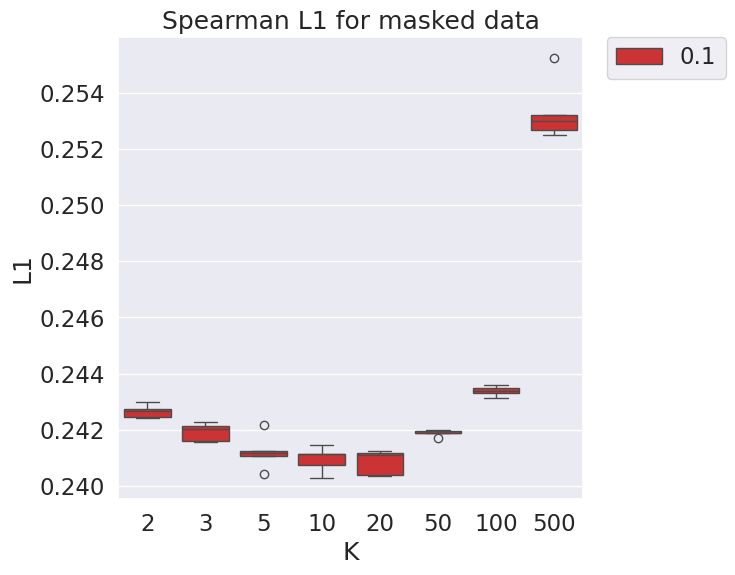

0.24027676218654154


In [108]:
# make boxplot of l1 error for each K and masking percentage
# sns.set_style("whitegrid")
import seaborn as sns
import matplotlib.pyplot as plt 

# make boxplot for r 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(6, 6))

ax = sns.boxplot(x="K", y="l1", data=masked_perf_df, palette="Set1", hue="perc_masked")
ax.set_xlabel("K")
ax.set_ylabel("L1")
ax.set_title("Spearman L1 for masked data")

# put legend on the outside 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

print(masked_perf_df.l1.min())


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


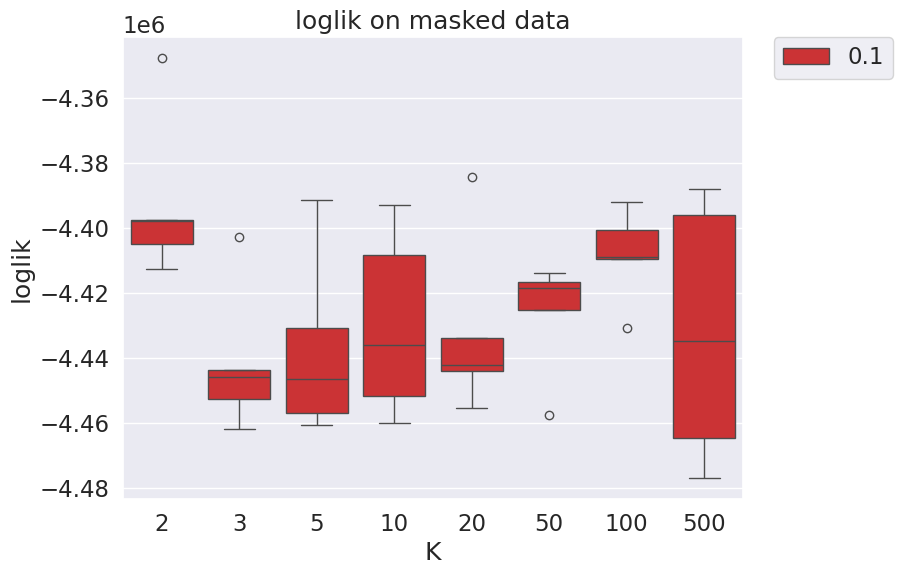

0.330530361746983


In [109]:
# make boxplot for rmse 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(8, 6))

ax = sns.boxplot(x="K", y="loglik", data=masked_perf_df, palette="Set1", hue="perc_masked")
ax.set_xlabel("K")
ax.set_ylabel("loglik")
ax.set_title("loglik on masked data")
# put legend on the outside 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()
print(masked_perf_df.rmse.min())

In [110]:
# get median l1 error and pearson r for each K and across all masking percentages
median_l1 = masked_perf_df.groupby(["K"])["l1"].median()
median_r = masked_perf_df.groupby(["K"])["r"].median()
median_l2 = masked_perf_df.groupby(["K"])["l2"].median()
median_rmse = masked_perf_df.groupby(["K"])["rmse"].median()
median_loglik = masked_perf_df.groupby(["K"])["loglik"].median()

# find K that gives the lowest l1 error and print it
min_l1 = median_l1.idxmin()
print("The K that gives the lowest median l1 error is: " + str(min_l1))

# find K that gives the lowest l2 error and print it
min_l2 = median_l2.idxmin()
print("The K that gives the lowest median l2 error is: " + str(min_l2))

# find K that gives the highest r and print it
max_r = median_r.idxmax()
print("The K that gives the highest median r is: " + str(max_r))

# find K that gives the lowest rmse and print it
min_rmse = median_rmse.idxmin()
print("The K that gives the lowest median rmse is: " + str(min_rmse))

# find K that gives the highest loglik and print it
max_loglik = median_loglik.idxmax()
print("The K that gives the higher median Log Likelihood is: " + str(max_loglik))

The K that gives the lowest median l1 error is: 20
The K that gives the lowest median l2 error is: 100
The K that gives the highest median r is: 50
The K that gives the lowest median rmse is: 100
The K that gives the higher median Log Likelihood is: 2


In [111]:
reload(factor_model)

2.3.0+cu121
12.1


<module 'factor_model' from '/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/factor_model.py'>

Using prior for a and b per junction to model average behaviour!
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Using a Beta-binomial distribution with concentration parameter 1.
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 1 with seed 8272
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 13231478.361214727
Epoch 40, Elbo loss: 9787538.56572427
Epoch 80, Elbo loss: 9243722.162811302
Epoch 120, Elbo loss: 9163660.539432691
Epoch 160, Elbo loss: 9125411.310064647
Epoch 200, Elbo loss: 9104330.89628825
Epoch 240, Elbo loss: 9092151.498091565
Epoch 280, Elbo loss: 9083075.903179038
Epoch 320, Elbo loss: 9076713.551765058
Epoch 360, Elbo loss: 9072495.713300362
Epoch 400, Elbo loss: 9068865.077658828
Epoch 440, Elbo loss: 9065590.430680027
Epoch 480, Elbo loss: 9

INFO:root:Elbo loss: 9062715.170265717


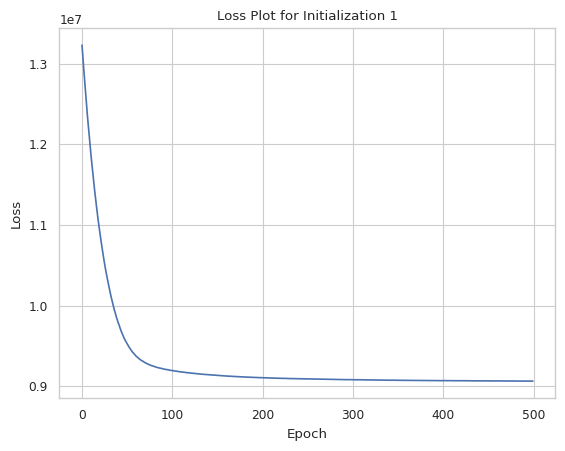

Sample from the guide (posterior)
Extract the latent variables
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 2 with seed 4348
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 13302496.447640695
Epoch 40, Elbo loss: 9806439.455772743


In [128]:
best_K = 10
K = best_K

# make input conc infinity first 
# input_conc = torch.tensor(np.inf, **float_type)

# import torch.distributions as dist
# input_conc = dist.Gamma(concentration=2.0, rate=2.0)

#input_conc = 1
all_results = factor_model.main(full_y_tensor, full_total_counts_tensor, num_initializations=2, use_global_prior=True, K=K, lr=0.05, loss_plot=True, num_epochs=500, save_to_file = False)

In [ ]:
metacells.iloc[1]

sample_name                    F2S4_160113_027_B01
exp_component_name             LS-15005h_S02_E1-50
specimen_type                              nucleus
cluster_color                              #E170FE
cluster_order                                 32.0
cluster_label                    Inh L2-5 VIP TOX2
class_color                                #0066FF
class_order                                    4.0
class_label                              GABAergic
subclass_color                             #996517
subclass_order                                 3.0
subclass_label                                 VIP
full_genotype_color                            NaN
full_genotype_order                            NaN
full_genotype_label                            NaN
donor_sex_color                            #3DCCCC
donor_sex_order                                  2
donor_sex_label                                  M
region_color                               #5CCCCC
region_order                   

In [ ]:
# keep only everything before "_/"
cell_ids_conversion["cell_id"] = cell_ids_conversion["cell_id"].str.split("_/").str[0]

In [ ]:
# rename sample_name column in metacells to cell_id
metacells = metacells.rename(columns={"sample_name": "cell_id"})
# rename class label to cell type
metacells = metacells.rename(columns={"class_label": "cell_type"})
metacells = metacells[["cell_id", "cell_type"]]
metacells.cell_type.value_counts()

cell_type
Glutamatergic    31229
GABAergic        11450
Non-neuronal      4753
Name: count, dtype: int64

In [ ]:
# remove cell_type column from cell_ids_conversion
cell_ids_conversion = cell_ids_conversion.drop(columns=["cell_type"])

In [ ]:
cell_ids_conversion

,cell_id_index,cell_id
0,0,F1S4_160106_001_D01
538,1,F1S4_160106_003_D01
2403,2,F1S4_160106_006_D01
4796,3,F1S4_160106_007_A01
4872,4,F1S4_160106_007_C01
...,...,...
2610990,2716,F2S4_190227_092_F01
2612310,2717,F2S4_190227_092_G01
2613649,2718,F2S4_190227_095_B01
2613977,2719,F2S4_190227_098_D01


In [ ]:
# merge cell_ids_conversion with metacells
cell_ids_conversion = cell_ids_conversion.merge(metacells, on="cell_id", how="left")

In [ ]:
cell_ids_conversion.cell_type.value_counts()

cell_type
Glutamatergic    1826
GABAergic         646
Non-neuronal      249
Name: count, dtype: int64

In [ ]:
# extract latent variables for just first seed used 
latent_vars = all_results[0]['latent_vars'] 
pi = latent_vars["pi"] # overall contribution of each factor to cell population, one value per k

dir_conc = latent_vars["dir_conc"] # one scaling value 

assign_post = latent_vars["assign"]

psis = latent_vars["psi"] # psi is the probability of a junction being used in a cluster

a = latent_vars["a"] 
b = latent_vars["b"] 
print(a)
print(b)

print("The inferred concentration parameter is: " + str(dir_conc))
print("The inferred pi parameter is: " + str(pi))

[0.59296143 1.0657701  0.8377631  ... 0.6270655  0.28398025 0.36227125]
[0.6084259 3.052944  5.4680085 ... 1.6692648 1.9928087 1.4626876]
The inferred concentration parameter is: 4.3138657
The inferred pi parameter is: [0.28496817 0.26135805 0.04977094 0.05199038 0.15785025 0.05496866
 0.04413979 0.03475115 0.02789546 0.03230723]


In [ ]:
# make UMAP using average assign_post across seeds and color points by cell_type 
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns

# run UMAP on assign_post matrix
reducer = umap.UMAP()
embedding = reducer.fit_transform(assign_post)

In [ ]:
cell_ids_conversion["cell_type"].value_counts()

cell_type
Glutamatergic    1826
GABAergic         646
Non-neuronal      249
Name: count, dtype: int64

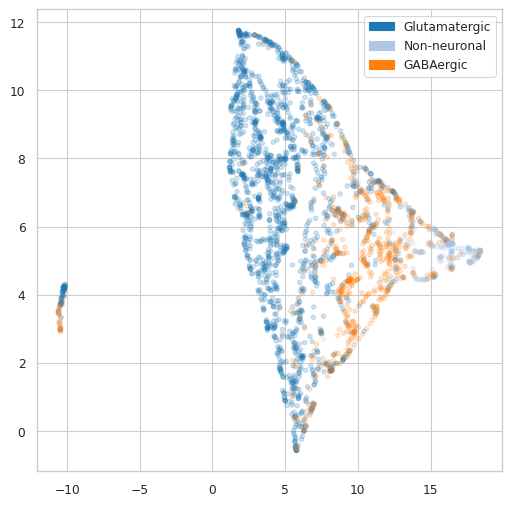

In [ ]:
# plot UMAP 
# add whitegrid 
import matplotlib.patches as mpatches

sns.set_style("whitegrid")
sns.set_context("paper")
plt.figure(figsize=(6, 6))

# remove nans from cell_ids_conversion
cell_ids_conversion = cell_ids_conversion.dropna(subset=["cell_type"])
# subset embedding to only the cell indices left 
embedding = embedding[cell_ids_conversion.index]

cell_types = cell_ids_conversion.cell_type

cell_types_unique = cell_types.unique()
cell_type_colors = sns.color_palette("tab20", len(cell_types_unique))
cell_type_dict = dict(zip(cell_types_unique, cell_type_colors))
cell_colors = cell_types.map(cell_type_dict)

# Plot the UMAP embedding
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    s=10, c=cell_colors, alpha=0.2
)

# Create legend handles and labels
legend_handles = [mpatches.Patch(color=color, label=cell_type) for cell_type, color in cell_type_dict.items()]

# Add legend to the plot
plt.legend(handles=legend_handles)

In [ ]:
pi = latent_vars["pi"] # overall contribution of each factor to cell population, one value per k
pi

array([0.28496817, 0.26135805, 0.04977094, 0.05199038, 0.15785025,
       0.05496866, 0.04413979, 0.03475115, 0.02789546, 0.03230723],
      dtype=float32)

         pi    Factor
0  0.284968  Facotor0
1  0.261358  Facotor1
4  0.157850  Facotor4
5  0.054969  Facotor5
3  0.051990  Facotor3


/scratch/ipykernel_133308/540431722.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Factor", y="pi", data=pi_df, palette="viridis")


Text(0.5, 1.0, 'Overall contribution of each factor to cell population')

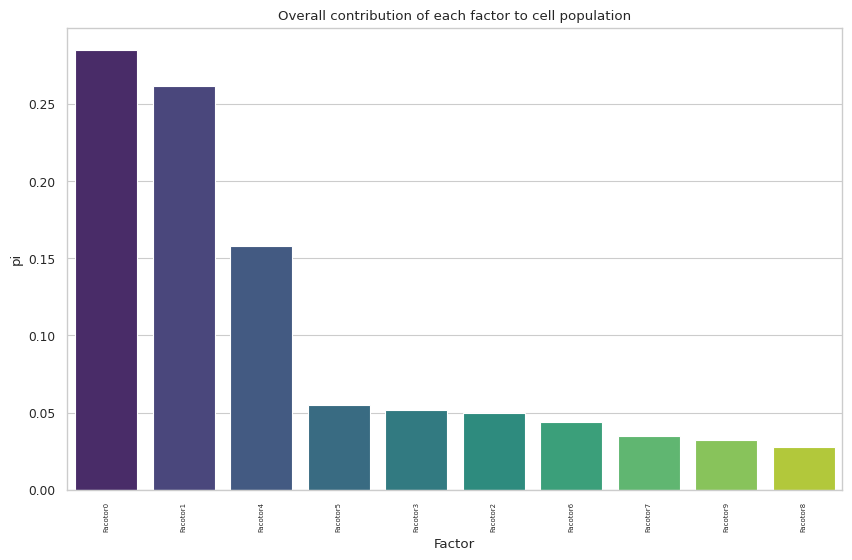

In [ ]:
# make sorted barplot of pi
pi_df = pd.DataFrame(pi, columns=["pi"])
# add factor number column 
pi_df["Factor"] = "Facotor"+pi_df.index.astype(str)
pi_df = pi_df.sort_values(by="pi", ascending=False)
print(pi_df.head())

# make barplot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="Factor", y="pi", data=pi_df, palette="viridis")
ax.set_xlabel("Factor")
# rotate x labels 90 degres 
plt.xticks(rotation=90, size=5)

ax.set_ylabel("pi")
ax.set_title("Overall contribution of each factor to cell population")

In [ ]:
# which splice junctions are very activated in factor 8 
psi = latent_vars["psi"]

# convert into a data frame
psi_df = pd.DataFrame(psi)

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


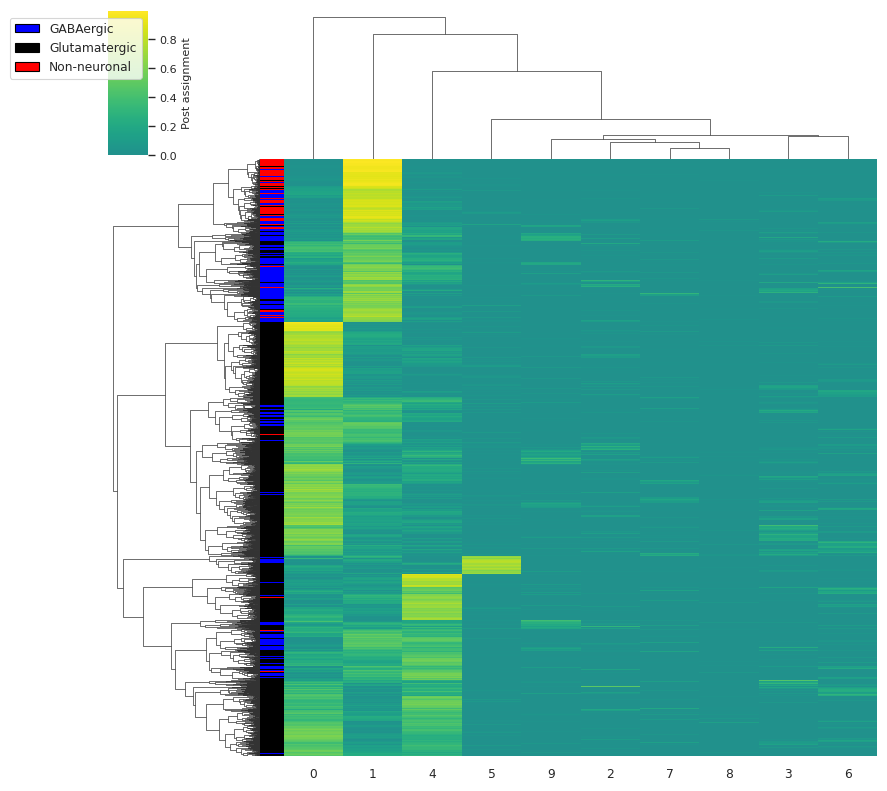

In [ ]:
import seaborn as sns
from matplotlib.patches import Patch

# Define your custom color palette
custom_palette = ["black", "red", "blue", "green", "orange", "purple", "pink", "grey", "yellow"]

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_ids_conversion['cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = custom_palette[:num_unique_types]  # Ensure you have enough colors in your custom palette

# Create a dictionary mapping cell types to colors
cell_type_colors = {cell_type: color for cell_type, color in zip(unique_cell_types, colors)}

# Get cell type labels for each cell
cell_types = cell_ids_conversion.cell_type.values

# Create a list of colors for each cell based on its cell type
row_colors = [cell_type_colors[cell_type] for cell_type in cell_types]

# subset assign_post to just the indices in cell_ids_conversion
assign_post = assign_post[cell_ids_conversion.index]

# Use the custom color palette in your clustermap
cluster = sns.clustermap(
    data=assign_post,
    method='complete',
    cmap="viridis",
    annot=False,
    fmt=".2f",
    yticklabels=False,
    figsize=(8, 8),
    center=0,
    row_colors=row_colors,  # Apply row colors
    cbar_kws={'label': 'Post assignment'} 
)

# Set label for color bar
cluster.cax.set_ylabel('Post assignment', size=8)

# Increase font size for color bar tick labels
cbar_ax = cluster.cax
for label in cbar_ax.yaxis.get_ticklabels():
    label.set_size(8)

legend_elements = [Patch(facecolor=cell_type_colors[key], edgecolor='black', label=str(key)) for key in sorted(cell_type_colors.keys())]
plt.legend(handles=legend_elements, loc='upper right')
